In this file we use polynomial regression to predict outcomes based on datasets. The process is very similar to that of linear regression and we can also use r2 as a measure of our model. As always, we start with our imports. If you need to you may need to run the pip installs

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

The dataset we are using compares the position level in a company to their salary. As always we load and take a look at the data

In [2]:
df = pd.read_csv('data/poly_salary.csv')
df.head()

,Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manger,5,110000


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Position  10 non-null     str  
 1   Level     10 non-null     int64
 2   Salary    10 non-null     int64
dtypes: int64(2), str(1)
memory usage: 372.0 bytes


Here we grab the two columns that we want, using the Python built in split to grab the level column

In [4]:
X = df.iloc[:, 1:2].values
y = df.iloc[:, 2].values

We'll create a regular linear model so we can compare against our polynomial model later

In [5]:
lin = LinearRegression()

lin.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


Here we create our polynomial model. To do so, we set the degree of polynomial data to what we want (higher degrees can lead to overfitting) and then we transform our X data into polynomial data based on the degree. Afterwards we make a line to fit the data using our normal linear regression class

In [ ]:
poly = PolynomialFeatures(degree=4)
X_poly = poly.fit_transform(X)

poly.fit(X_poly, y)
poly_reg = LinearRegression()
poly_reg.fit(X_poly, y)

[[1.000e+00 1.000e+00 1.000e+00 1.000e+00 1.000e+00]
 [1.000e+00 2.000e+00 4.000e+00 8.000e+00 1.600e+01]
 [1.000e+00 3.000e+00 9.000e+00 2.700e+01 8.100e+01]
 [1.000e+00 4.000e+00 1.600e+01 6.400e+01 2.560e+02]
 [1.000e+00 5.000e+00 2.500e+01 1.250e+02 6.250e+02]
 [1.000e+00 6.000e+00 3.600e+01 2.160e+02 1.296e+03]
 [1.000e+00 7.000e+00 4.900e+01 3.430e+02 2.401e+03]
 [1.000e+00 8.000e+00 6.400e+01 5.120e+02 4.096e+03]
 [1.000e+00 9.000e+00 8.100e+01 7.290e+02 6.561e+03]
 [1.000e+00 1.000e+01 1.000e+02 1.000e+03 1.000e+04]]


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


We have two graphs below to compare our lines

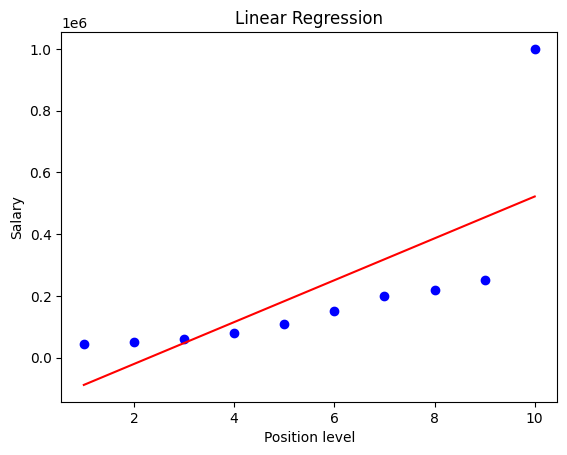

In [7]:
plt.scatter(X, y, color='blue')

plt.plot(X, lin.predict(X), color='red')
plt.title('Linear Regression')
plt.xlabel('Position level')
plt.ylabel('Salary')

plt.show()

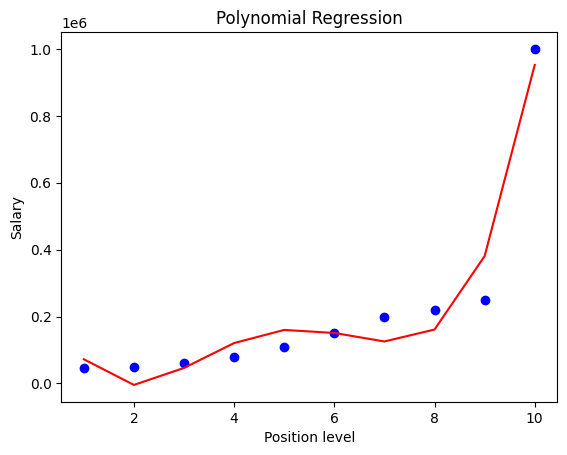

In [8]:
plt.scatter(X, y, color='blue')

plt.plot(X, poly_reg.predict(poly.fit_transform(X)),
         color='red')
plt.title('Polynomial Regression')
plt.xlabel('Position level')
plt.ylabel('Salary')

plt.show()

We can see that our polynomial model is better than our linear one and we can compare our r2 values. Another method of comparing models is the mean squared error (MSE). We generally want this score to be close to 0 (don't stress if you're getting big numbers if the data is using large numbers). We also generally use this to compare models rather than purely for self-testing

In [9]:
y_pred = poly_reg.predict(X_poly)
mse = mean_squared_error(y, y_pred)
r2 = r2_score(y, y_pred)

print(mse)
print(r2)

3643560606.060588
0.9501771072017313


We can also get these for our linear model

In [10]:
y_pred_lin = lin.predict(X)
mse_lin = mean_squared_error(y, y_pred_lin)
r2_lin = r2_score(y, y_pred_lin)

print(mse_lin)
print(r2_lin)

35152060606.0606
0.5193225702625028


We can see that our r2 model is way better for our polynomial model and while our MSE looks really large for both the polynomial one is actually 10 times smaller

We can also use a polynomial model on a dataset with multiple factors like with linear regrssion which we have done below

In [11]:
data = pd.read_csv('data/Updated Quality of Life Data.csv')
data.head()

,id,gender,occupation_type,avg_work_hours_per_day,avg_rest_hours_per_day,avg_sleep_hours_per_day,avg_exercise_hours_per_day,age_at_death
0,10001,Female,Teacher,6.60,10.92,5.38,1.10,88
1,10002,Male,Office Worker,9.65,7.65,6.31,0.39,76
2,10003,Female,Manager,13.77,1.00,8.02,1.21,78
3,10004,Female,Freelancer,10.94,5.18,7.59,0.29,74
4,10005,Male,Engineer,9.81,5.11,7.38,1.70,78


I have opted to not use occupation type for this example as I don't want to go through the trouble of mapping each possibility. However, I have opted to include gender which is a string in this dataset so I map it to numbers later

In [12]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          10000 non-null  int64  
 1   gender                      10000 non-null  str    
 2   occupation_type             10000 non-null  str    
 3   avg_work_hours_per_day      10000 non-null  float64
 4   avg_rest_hours_per_day      10000 non-null  float64
 5   avg_sleep_hours_per_day     10000 non-null  float64
 6   avg_exercise_hours_per_day  10000 non-null  float64
 7   age_at_death                10000 non-null  int64  
dtypes: float64(4), int64(2), str(2)
memory usage: 625.1 KB


I was having trouble with nulls while making this so I've left this in here as a note that you can use this to check for nulls

In [13]:
data.isnull().sum()

id                            0
gender                        0
occupation_type               0
avg_work_hours_per_day        0
avg_rest_hours_per_day        0
avg_sleep_hours_per_day       0
avg_exercise_hours_per_day    0
age_at_death                  0
dtype: int64

Let's plot our data as usual. We can see some patterns from the data namely we can see a sharp drop in life expectancy if you work around 20 hours a day or sleep 15 or more hours a day

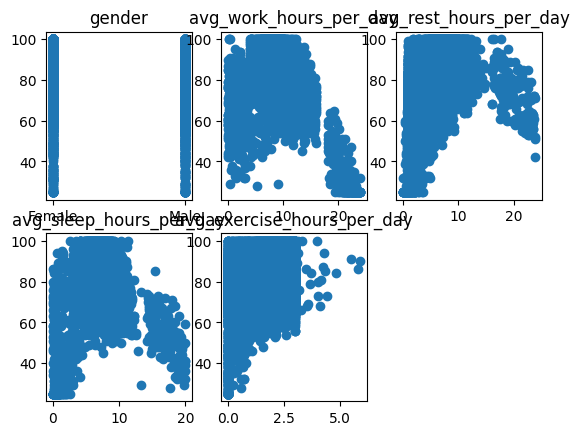

In [14]:

features = ['gender', 'avg_work_hours_per_day', 'avg_rest_hours_per_day', 'avg_sleep_hours_per_day', 'avg_exercise_hours_per_day']

for i, col in enumerate(features):
  plt.subplot(2,3,i+1)
  plt.title(features[i])
  plt.scatter(data[col], data['age_at_death'])
plt.show()

Here we map our gender data then load our data in

In [15]:
data['gender'] = data['gender'].map({'Female': 0, 'Male': 1})

X_2 = data[['gender','avg_work_hours_per_day', 'avg_rest_hours_per_day', 'avg_sleep_hours_per_day', 'avg_exercise_hours_per_day']]
y_2 = data['age_at_death']

As before we create our model. We also split the data into training and testing data, then fit it

In [16]:
poly_2 = PolynomialFeatures(degree = 3, include_bias = False)
X_2_poly = poly_2.fit_transform(X_2)

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X_2_poly, y_2, test_size=0.3, random_state=42)

In [18]:
poly_model = LinearRegression()
poly_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


Below we can test our model using MSE and r2. We find that for both the training and test data we get pretty low scores indicating that life expectancy may be more complex or our model simply isn't that great for this specific instance

In [19]:
mse_train = mean_squared_error(y_train, poly_model.predict(X_train))
r2_train = r2_score(y_train, poly_model.predict(X_train))
print(f"Mean Squared Error: {mse_train}")
print(f"R-squared: {r2_train}")

Mean Squared Error: 60.990204835772495
R-squared: 0.5757584981797004


In [20]:
y_pred = poly_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

Mean Squared Error: 62.90617796885785
R-squared: 0.5706559195212744
